Epoch 1/10
1875/1875 [==============================] - 99s 52ms/step - loss: 0.0943
Epoch 2/10
1875/1875 [==============================] - 101s 54ms/step - loss: 0.0888
Epoch 3/10
1875/1875 [==============================] - 96s 51ms/step - loss: 0.0881
Epoch 4/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.0878
Epoch 5/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.0876
Epoch 6/10
1875/1875 [==============================] - 94s 50ms/step - loss: 0.0874
Epoch 7/10
1875/1875 [==============================] - 98s 52ms/step - loss: 0.0873
Epoch 8/10
1875/1875 [==============================] - 95s 51ms/step - loss: 0.0872
Epoch 9/10
1875/1875 [==============================] - 97s 52ms/step - loss: 0.0871
Epoch 10/10
1/1 [==============================] - 0s 183ms/step


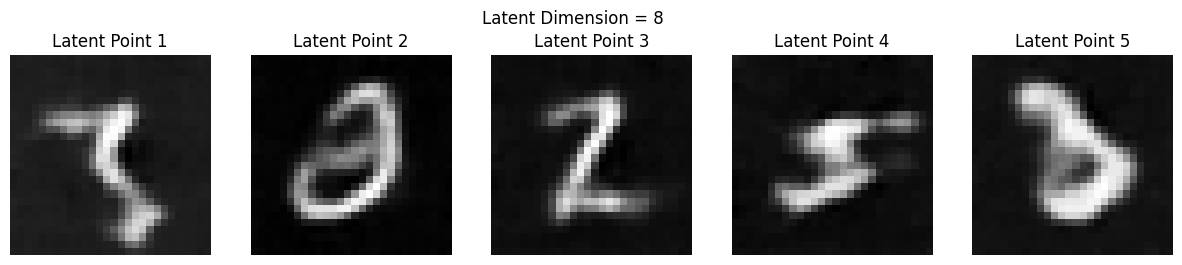

Epoch 1/10
1875/1875 [==============================] - 99s 52ms/step - loss: 0.0909
Epoch 2/10
1875/1875 [==============================] - 97s 52ms/step - loss: 0.0845
Epoch 3/10
1875/1875 [==============================] - 98s 52ms/step - loss: 0.0838
Epoch 4/10
1875/1875 [==============================] - 97s 52ms/step - loss: 0.0835
Epoch 5/10
1875/1875 [==============================] - 97s 52ms/step - loss: 0.0833
Epoch 6/10
1875/1875 [==============================] - 97s 52ms/step - loss: 0.0832
Epoch 7/10
1875/1875 [==============================] - 96s 51ms/step - loss: 0.0831
Epoch 8/10
1875/1875 [==============================] - 103s 55ms/step - loss: 0.0830
Epoch 9/10
1612/1875 [========================>.....] - ETA: 13s - loss: 0.0829

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models

# Load MNIST dataset
(train_images, _), (_, _) = keras.datasets.mnist.load_data()


# Preprocess the data
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32') / 255

# Add noise to the images
noise_factor = 0.5
train_noisy_images = train_images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=train_images.shape)
train_noisy_images = np.clip(train_noisy_images, 0., 1.)

# Define Diffusion model architecture
class DiffusionModel(models.Model):
    def __init__(self, latent_dim):
        super(DiffusionModel, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = self.build_encoder()
        self.decoder = self.build_decoder()

    def build_encoder(self):
        inputs = layers.Input(shape=(28, 28, 1))
        x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
        x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.Flatten()(x)
        z_mean = layers.Dense(self.latent_dim, name='z_mean')(x)
        z_log_var = layers.Dense(self.latent_dim, name='z_log_var')(x)
        return models.Model(inputs, [z_mean, z_log_var])

    def build_decoder(self):
        inputs = layers.Input(shape=(self.latent_dim,))
        x = layers.Dense(7 * 7 * 64, activation='relu')(inputs)
        x = layers.Reshape((7, 7, 64))(x)
        x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
        outputs = layers.Conv2DTranspose(1, 3, strides=1, padding='same', activation='sigmoid')(x)
        return models.Model(inputs, outputs)

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        epsilon = tf.random.normal(tf.shape(z_mean))
        sampled_latent = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        reconstructed = self.decoder(sampled_latent)
        return reconstructed

# Compile and train the model
def compile_and_train(model, train_data, epochs=10, batch_size=32):
    model.compile(optimizer='adam', loss='mse')
    model.fit(train_data, train_data, epochs=epochs, batch_size=batch_size)

# Function to generate images for different latent dimensions
def generate_images(latent_dim, train_data):
    # Instantiate the model
    model = DiffusionModel(latent_dim)

    # Compile and train the model
    compile_and_train(model, train_data)

    # Randomly sample 5 points from the latent vector space
    latent_points = np.random.normal(size=(5, latent_dim))

    # Generate output images for each latent point
    output_images = model.decoder.predict(latent_points)

    # Visualize the generated images
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):
        axs[i].imshow(output_images[i, :, :, 0], cmap='gray')
        axs[i].axis('off')
        axs[i].set_title(f'Latent Point {i+1}')
    plt.suptitle(f'Latent Dimension = {latent_dim}')
    plt.show()

# Latent dimensions to explore
latent_dims = [8, 16, 32, 64]

# Generate images for each latent dimension
for dim in latent_dims:
    generate_images(dim, train_noisy_images)